# Imports

In [ ]:
import re, random, time
from pathlib import Path
from typing import List, Dict, Tuple

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


import torch
from torch.utils.data import Dataset, DataLoader


import torchvision
from torchvision.transforms import functional as TF
from torchvision.models.detection import RetinaNet_ResNet50_FPN_V2_Weights, FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection import retinanet_resnet50_fpn_v2
from torchvision.models.detection.retinanet import RetinaNetClassificationHead
from torchmetrics.detection.mean_ap import MeanAveragePrecision


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


# Data Preprocessing and creating data Loaders

## Banana

In [65]:
## Data Preprocessing 
import xml.etree.ElementTree as ET
import torchvision.transforms as T

class BananaDataset(Dataset):
    def __init__(self, images_dir, annotations_dir, transform=None):
        self.images_dir = Path(images_dir)
        self.annotations_dir = Path(annotations_dir)
        self.images = sorted(list(self.images_dir.glob("*.jpg")))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        ann_path = self.annotations_dir / (img_path.stem + ".xml")

        img = Image.open(img_path).convert("RGB")
        width, height = img.size

        boxes = []
        labels = []

        tree = ET.parse(ann_path)
        root = tree.getroot()

        for obj in root.findall("object"):
            if obj.find("name").text == "banana":
                labels.append(1)

                bndbox = obj.find("bndbox")
                xmin = float(bndbox.find("xmin").text)
                ymin = float(bndbox.find("ymin").text)
                xmax = float(bndbox.find("xmax").text)
                ymax = float(bndbox.find("ymax").text)

                boxes.append([xmin, ymin, xmax, ymax])

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        # Resize image to 512x512
        new_size = 512
        scale_x = new_size / width
        scale_y = new_size / height

        boxes[:, [0,2]] *= scale_x
        boxes[:, [1,3]] *= scale_y

        img = img.resize((new_size, new_size))
        img = T.ToTensor()(img)

        area = (boxes[:,2] - boxes[:,0]) * (boxes[:,3] - boxes[:,1])
        iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx]),
            "area": area,
            "iscrowd": iscrowd,
        }

        return img, target

Create DataLoaders

In [67]:
def collate_fn(batch):
    return tuple(zip(*batch))

train_dataset = BananaDataset(
    "banana/images/train",
    "banana/annotations/train"
)

val_dataset = BananaDataset(
    "banana/images/test",
    "banana/annotations/test"
)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)

# Visualize two samples of the Training Data

## Banana

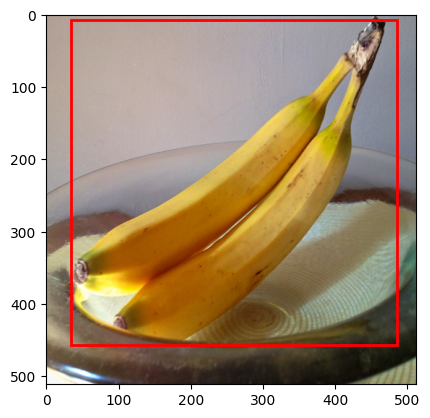

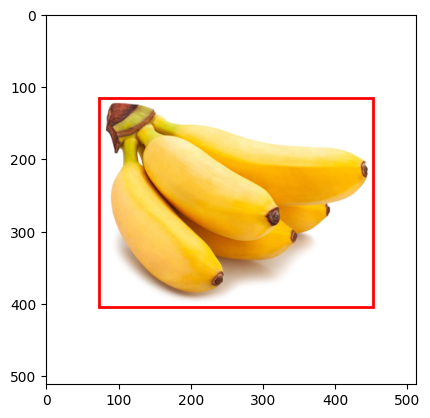

In [68]:
def visualize_sample(dataset, idx):
    img, target = dataset[idx]
    img_np = img.permute(1,2,0).numpy()

    plt.imshow(img_np)
    for box in target["boxes"]:
        x1,y1,x2,y2 = box
        plt.gca().add_patch(
            plt.Rectangle((x1,y1), x2-x1, y2-y1,
                          fill=False, edgecolor='red', linewidth=2)
        )
    plt.show()

visualize_sample(train_dataset, 0)
visualize_sample(train_dataset, 1)

# Create the following methods for training and evaluation:
### 1.train_one_epoch
### 2.evaluate_map (mean Average Precision)
### 3.time_inference

In [ ]:
def train_one_epoch(model, loader, optimizer, device, epoch=None):
    ### You Code Here ###
    model.train()
    total_loss = 0

    for images, targets in loader:
        images = [img.to(device) for img in images]
        targets = [{k:v.to(device) for k,v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate_map(model, loader, device):
    """mAP evaluation using torchmetrics.
    Returns a dict with keys like 'map', 'map_50', 'mar_100', ...
    """
    ### You Code Here ##
    model.eval()
    metric = MeanAveragePrecision()

    for images, targets in loader:
        images = [img.to(device) for img in images]
        outputs = model(images)

        preds = [{k:v.cpu() for k,v in o.items()} for o in outputs]
        targets = [{k:v.cpu() for k,v in t.items()} for t in targets]

        metric.update(preds, targets)


    return metric.compute()


@torch.no_grad()
def time_inference(model, dataset, device, n_images=100, warmup=10):
    """Average inference time per image (ms)."""
    ### You Code Here ###
    model.eval()
    times = []

    n_images = min(n_images, len(dataset))
    indices = random.sample(range(len(dataset)), n_images)

    # Warmup
    for i in indices[:warmup]:
        img, _ = dataset[i]
        img = img.to(device)
        _ = model([img])

    # Measure inference time 
    for i in indices:
        img, _ = dataset[i]
        img = img.to(device)

        start = time.time()
        _ = model([img])
        end = time.time()

        times.append((end - start) * 1000)# ms

    return float(np.mean(times)), float(np.std(times))


# Create Two-stage detector: Faster R-CNN (Region Proposal + classifier)

We'll fine-tune a Faster R-CNN model. To do this:
1- Load the fasterRCN.
2- Freeze the backbone.
3- create an optimizer for it. SGD with lr=0.005, momentum=0.9, weight_decay=0.0005

Note: In TorchVision detection models like Faster R-CNN, num_classes means: number of foreground categories + 1 background class

## Banana

In [71]:
# Number of classes: background + banana
num_classes = 2

# 1 Load pretrained Faster R-CNN
weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
model_faster = torchvision.models.detection.fasterrcnn_resnet50_fpn_v2(weights=weights)

# Replace classifier head
in_features = model_faster.roi_heads.box_predictor.cls_score.in_features
model_faster.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features, num_classes
)

# 2 Freeze backbone
for param in model_faster.backbone.parameters():
    param.requires_grad = False

model_faster.to(device)

# 3 Optimizer
optimizer_faster = torch.optim.SGD(
    filter(lambda p: p.requires_grad, model_faster.parameters()),
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)


## Train for small number of epochs

## Banana

In [73]:
num_epochs = 5

for epoch in range(num_epochs):
    loss = train_one_epoch(model_faster, train_loader, optimizer_faster, device)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss:.4f}")

Epoch 1/5, Loss: 0.2455
Epoch 2/5, Loss: 0.1249
Epoch 3/5, Loss: 0.1049
Epoch 4/5, Loss: 0.1019
Epoch 5/5, Loss: 0.0899


# Create One-stage detector: RetinaNet

We'll fine-tune RetinaNet. To do this:
1- Load the RetinaNet.
2- Freeze the backbone.
3- create an optimizer for it. SGD with lr=0.005, momentum=0.9, weight_decay=0.0005


Note: In TorchVision detection models, num_classes means: number of foreground categories + 1 background class


## Banana

In [74]:
#Create model RetinaNet

num_classes = 2  # background + banana

model_retina = retinanet_resnet50_fpn_v2(pretrained=True)

# Get number of anchors
num_anchors = model_retina.head.classification_head.num_anchors

# Replace classification head
model_retina.head.classification_head = RetinaNetClassificationHead(
    in_channels=256,
    num_anchors=num_anchors,
    num_classes=num_classes
)

model_retina.to(device)

C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=RetinaNet_ResNet50_FPN_V2_Weights.COCO_V1`. You can also use `weights=RetinaNet_ResNet50_FPN_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


RetinaNet(
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      

In [75]:
#Freeze backbone
for param in model_retina.backbone.parameters():
    param.requires_grad = False

#Optimizer
optimizer_retina = torch.optim.SGD(
    filter(lambda p: p.requires_grad, model_retina.parameters()),
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

In [76]:
num_epochs = 5

for epoch in range(num_epochs):
    loss = train_one_epoch(model_retina, train_loader, optimizer_faster, device)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss:.4f}")

Epoch 1/5, Loss: 1.2755
Epoch 2/5, Loss: 1.2775
Epoch 3/5, Loss: 1.2827
Epoch 4/5, Loss: 1.2812
Epoch 5/5, Loss: 1.2750


## Calculate val_mAP, val_mAP50, mean_infer_ms for both methods

In [77]:
# FasterRCNN
map_faster = evaluate_map(model_faster, val_loader, device)
print("FasterRCNN Results:")
print(map_faster)

# RetinaNet
map_retina = evaluate_map(model_retina, val_loader, device)
print("RetinaNet Results:")
print(map_retina)

FasterRCNN Results:
{'map': tensor(0.6386), 'map_50': tensor(0.9201), 'map_75': tensor(0.8014), 'map_small': tensor(-1.), 'map_medium': tensor(-1.), 'map_large': tensor(0.6397), 'mar_1': tensor(0.6196), 'mar_10': tensor(0.7130), 'mar_100': tensor(0.7130), 'mar_small': tensor(-1.), 'mar_medium': tensor(-1.), 'mar_large': tensor(0.7130), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor(1, dtype=torch.int32)}
RetinaNet Results:
{'map': tensor(0.), 'map_50': tensor(0.), 'map_75': tensor(0.), 'map_small': tensor(-1.), 'map_medium': tensor(-1.), 'map_large': tensor(0.), 'mar_1': tensor(0.), 'mar_10': tensor(0.), 'mar_100': tensor(0.), 'mar_small': tensor(-1.), 'mar_medium': tensor(-1.), 'mar_large': tensor(0.), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor(1, dtype=torch.int32)}


In [78]:
mean_faster, std_faster = time_inference(model_faster, val_dataset, device)
print(f"FasterRCNN inference time: {mean_faster:.2f} ± {std_faster:.2f} ms")

mean_retina, std_retina = time_inference(model_retina, val_dataset, device)
print(f"RetinaNet inference time: {mean_retina:.2f} ± {std_retina:.2f} ms")

FasterRCNN inference time: 3410.09 ± 607.98 ms
RetinaNet inference time: 2267.66 ± 153.21 ms


## Visualize the results of two methods for couple of images from test set

In [84]:
def visualize_predictions(model, dataset, device, num_images=3):
    model.eval()

    indices = random.sample(range(len(dataset)), num_images)

    for idx in indices:
        img, target = dataset[idx]
        with torch.no_grad():
            output = model([img.to(device)])[0]

        img_np = img.permute(1,2,0).numpy()

        plt.figure(figsize=(6,6))
        plt.imshow(img_np)

        # Ground truth (green)
        for box in target["boxes"]:
            xmin, ymin, xmax, ymax = box
            plt.gca().add_patch(
                plt.Rectangle(
                    (xmin, ymin),
                    xmax-xmin,
                    ymax-ymin,
                    fill=False,
                    color="green",
                    linewidth=2
                )
            )

        # Predictions (red)
        for box, score in zip(output["boxes"], output["scores"]):
            if score > 0.5:
                xmin, ymin, xmax, ymax = box.cpu()
                plt.gca().add_patch(
                    plt.Rectangle(
                        (xmin, ymin),
                        xmax-xmin,
                        ymax-ymin,
                        fill=False,
                        color="red",
                        linewidth=2
                    )
                )

        plt.title("Green: GT | Red: Prediction")
        plt.show()

FasterRCNN predictions:


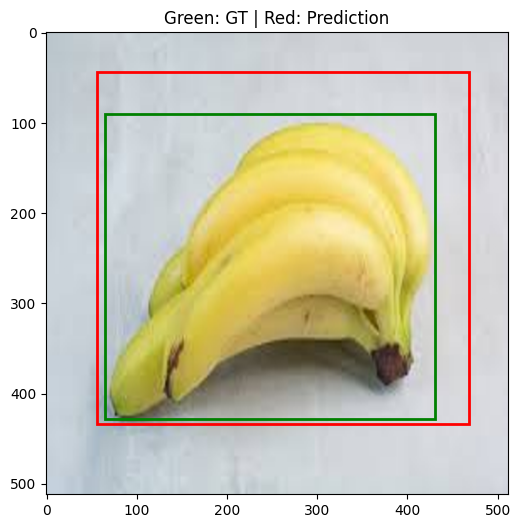

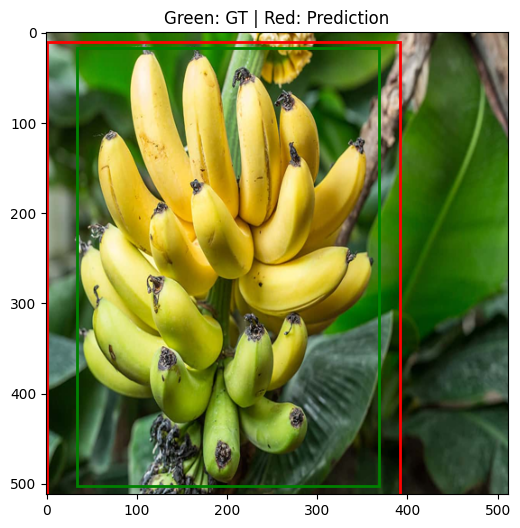

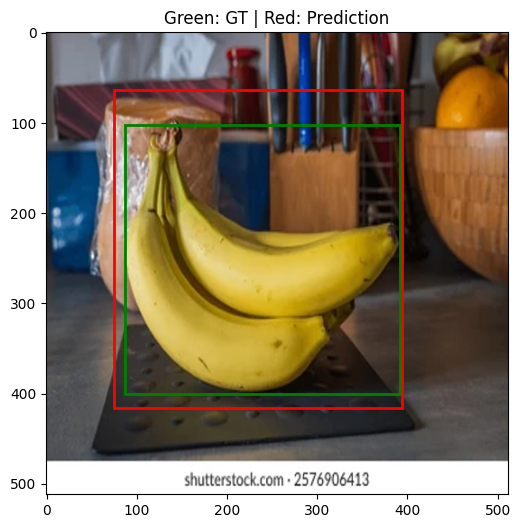

RetinaNet predictions:


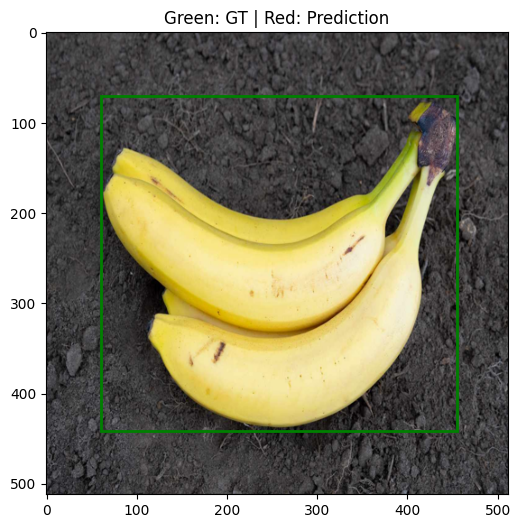

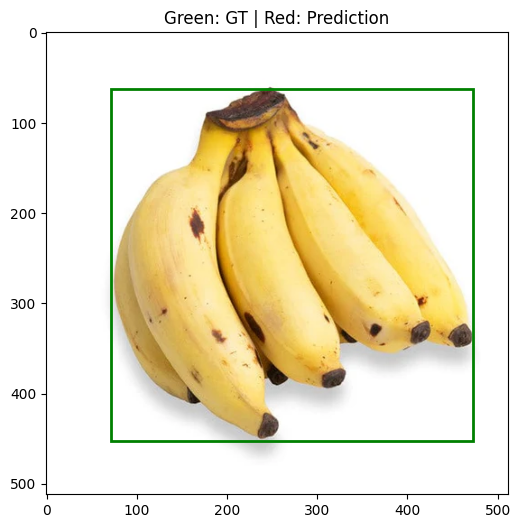

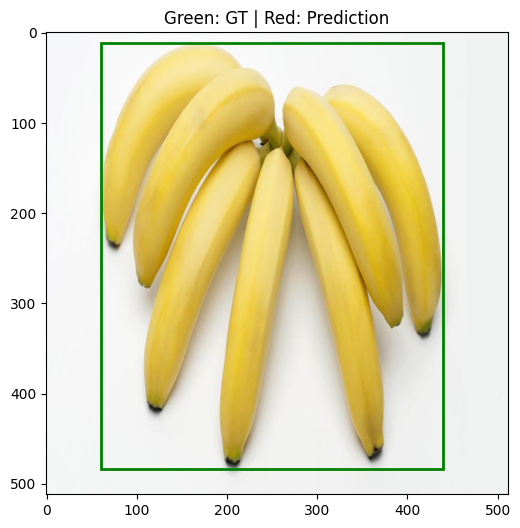

In [86]:
print("FasterRCNN predictions:")
visualize_predictions(model_faster, val_dataset, device)

print("RetinaNet predictions:")
visualize_predictions(model_retina, val_dataset, device)

## Conclusion

In this project, I compared Faster R-CNN (two-stage) and RetinaNet (one-stage) on a custom banana detection dataset (my own dataset).

Faster R-CNN achieved clearly better detection performance, with a strong mAP and high mAP50. On the other hand, RetinaNet struggled to learn effectively under the same settings, resulting in very low mAP. Since the backbone was frozen and the dataset was relatively small, RetinaNet did not have enough capacity to adapt, while Faster R-CNN handled the limited data more robustly.

In terms of speed, RetinaNet showed slightly faster inference time, which matches the general expectation that one-stage detectors are computationally more efficient.

Overall, the results highlight the typical trade-off: two-stage detectors tend to perform better on small datasets, while one-stage detectors may require more data and training to achieve comparable accuracy.